# mixed death 

In [ ]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/home/esraan/CellDeathSpreading/code/")

from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mSpiCalc import mSpiCalc
from src.mixSpiCalc import mixSpiCalc

In [2]:
def plot_histogram_with_lines(values, observed, shuffled_5_per, bins=30, title="Value Distribution", xlabel="Value", ylabel="Frequency", text=None, text_position=(0.5, 0.9)):
    """
    Plot a histogram of the given values with two vertical lines for precomputed values and optional text.

    Parameters:
    - values: list or array of 1000 numeric values
    - observed: float, position of the first vertical reference line
    - shuffled_5_per: float, position of the second vertical reference line
    - bins: int, number of histogram bins
    - title: str, title of the plot
    - xlabel: str, label for the x-axis
    - ylabel: str, label for the y-axis
    - text: str, optional text to display on the plot
    - text_position: tuple, position of the text in axes coordinates (x, y)
    """

    # Set colorblind-friendly palette
    sns.set_palette("colorblind")
    sns.set_context("talk")  # For better font sizes
    sns.set_style("whitegrid")

    # Create the histogram
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(values, bins=bins, kde=False, color=sns.color_palette("colorblind")[0])

    # Plot vertical lines
    plt.axvline(observed, color=sns.color_palette("colorblind")[2], linestyle="--", linewidth=2, label=f"observed = {observed:.2f}")
    plt.axvline(shuffled_5_per, color=sns.color_palette("colorblind")[1], linestyle="--", linewidth=2, label=f"shuffled 5% = {shuffled_5_per:.2f}")

    # Add text to the plot if provided
    if text:
        plt.text(text_position[0], text_position[1], text, fontsize=14, transform=plt.gca().transAxes, ha='center')

    # Axis labels and title
    plt.title(title, fontsize=20)
    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel(ylabel, fontsize=16)

    # Tick label formatting
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Legend
    plt.legend(fontsize=12, loc="upper right")
    plt.grid(False)
    plt.tight_layout()
    plt.show()


0.24800000000000003


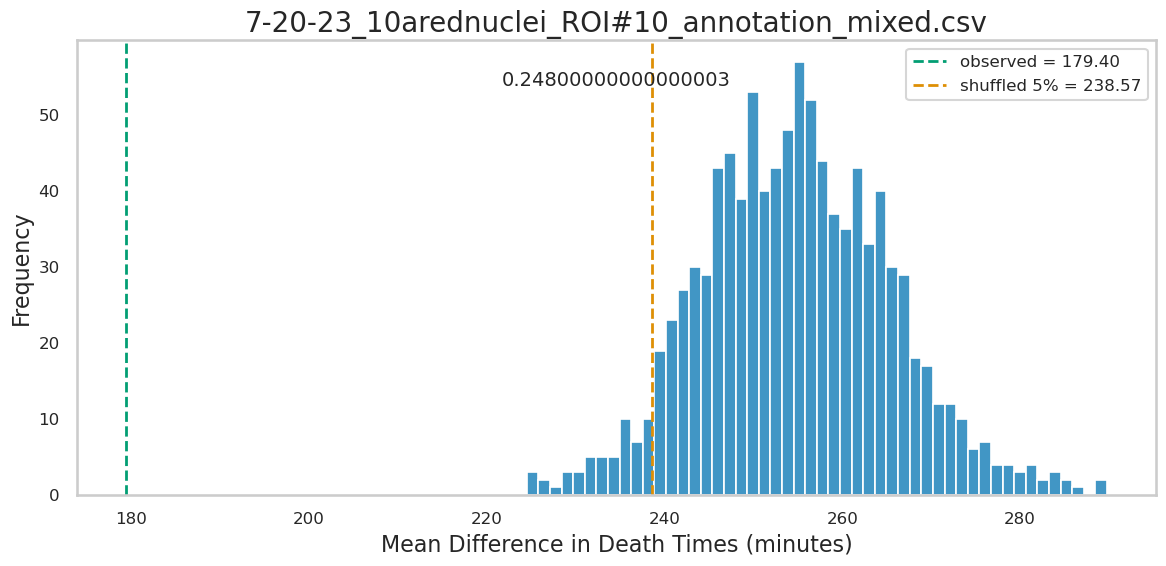

0.2119355045930495


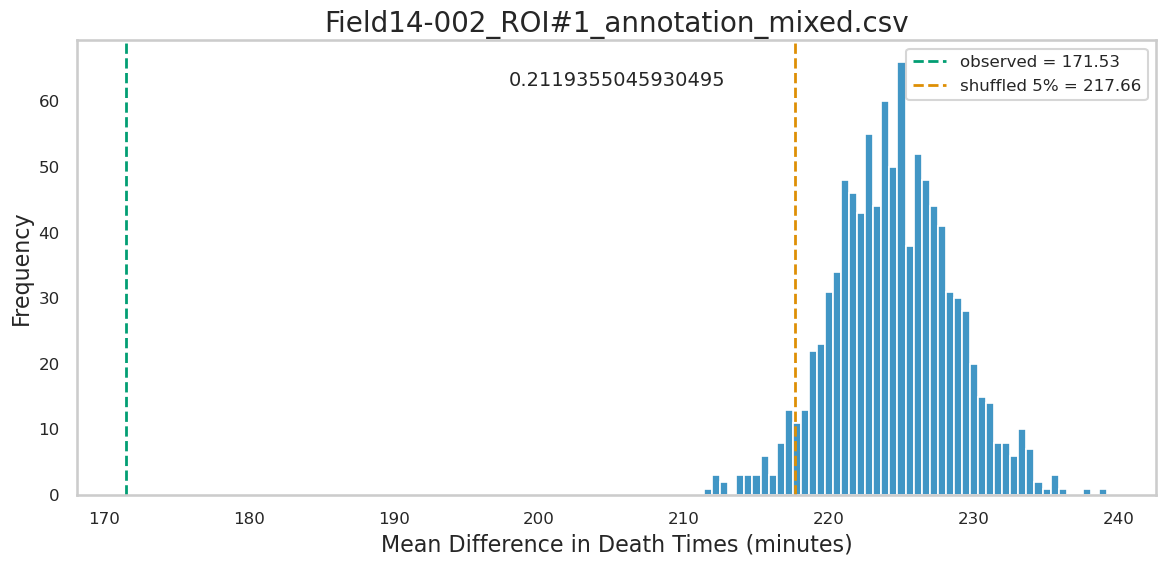

0.16945754955757575


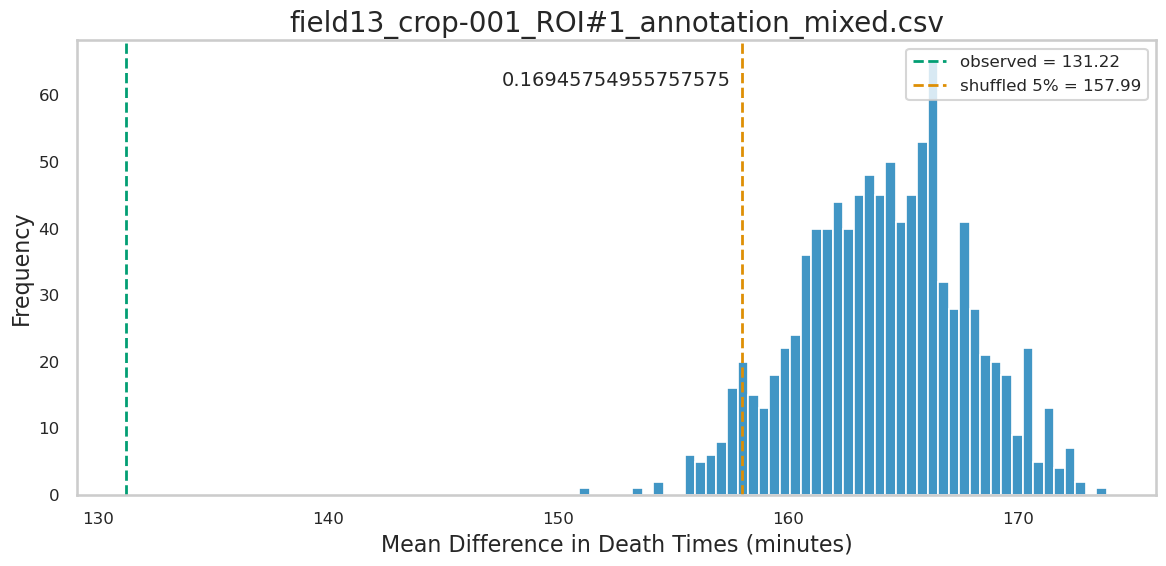

0.3837817355058734


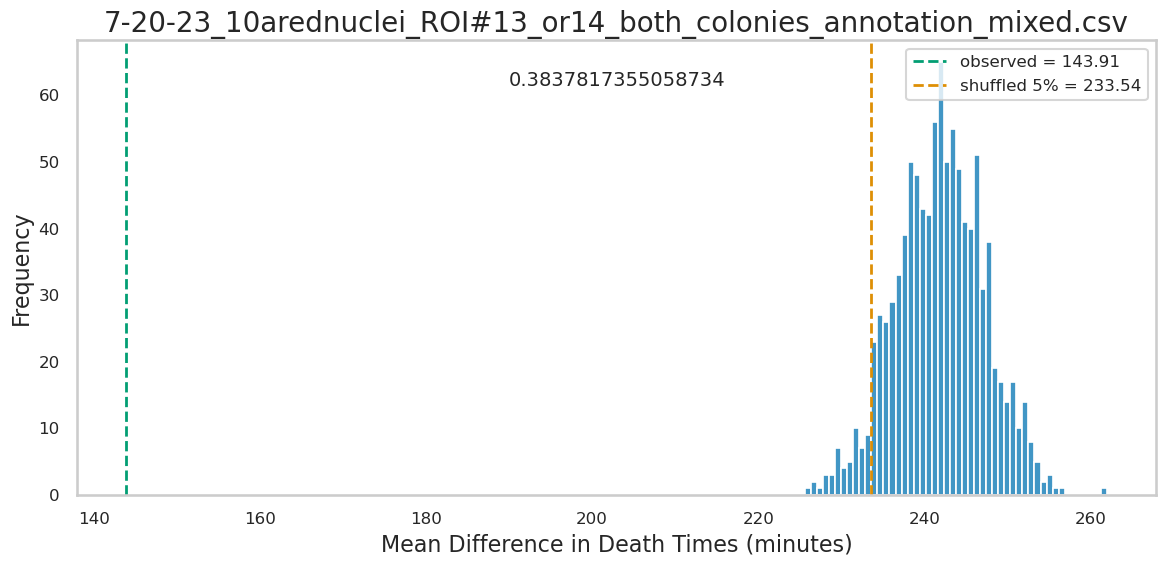

In [ ]:
single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only/'#Field14-002_ROI#1_annotation_nec.csv'
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    if '_mixed' not in file:
        continue
    cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
    csv = pd.read_csv(os.path.join(single_exp_full_paths, file))
    death_mode = csv["Mode"].values
    ob = mixSpiCalc(XY=cells_loci,
                        die_times=cells_times_of_death,
                        death_mode = death_mode,
                        treatment='ML162',
                        temporal_resolution=10,
                        n_scramble=1000,
                        draw=False,
                        dist_threshold=50, 
                        filter_neighbors_by_distance=True,
                        filter_neighbors_by_level= 1,
                        time_unit='minutes',)
    print(ob.get_uspis())
    mean_of_shuffles = ob.all_mean_shuffles_sorted
    # flattened_array = np.concatenate(mean_of_shuffles).ravel().tolist()
    flattened_array = np.array(mean_of_shuffles)
    # print(flattened_array)
    mean_5_pre =  ob.scramble_signficance_95
    mean_observed = ob.original_difference_death_times
    plot_histogram_with_lines(flattened_array, observed=mean_observed, shuffled_5_per= mean_5_pre, bins=50, title=file, xlabel="Mean Difference in Death Times (minutes)", ylabel="Frequency", text = str(ob.get_uspis()))

# Segregation Index

In [ ]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/home/esraan/CellDeathSpreading/src/")

from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mSpiCalc import mSpiCalc
from src.mixSpiCalc import mixSpiCalc

In [16]:

single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'#Field14-002_ROI#1_annotation_nec.csv'
# single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_sytox/'
res = {}
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    print(file)
    if '_mixed' not in file:
        continue
    # print(file)
    cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
    exp_full_path = os.path.join(single_exp_full_paths, file)
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 33
    death_modes = csv_file[["Mode"]].values
    # np.random.shuffle(death_modes)
    segregation_index = SegregationIdx(cells_loci, death_modes,1000, dist_threshold, filter_neighbors_by_distance=True, neighbors_level=1, stats_to_calculate= "mean")
    seg_res_dict = segregation_index.get_segregation_index()
    print(seg_res_dict)
    res[file] = {key: (value[0]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')} #(value[0]/value[2])



3-19-2924_10ah2bmcherry_ROI#2_annotation_nec.csv
Field14-002_ROI#1_annotation_nec.csv
20181227_MCF10A_SKT_xy3.csv
20181227_MCF10A_SKT_xy5.csv
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv
{'apoptosis': (0.9425931259600615, 0.0, 0.41680672268907565), 'necrosis': (0.9586318100727323, 0.0, 0.5831932773109244)}
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_nec.csv
7-20-23_10arednuclei_ROI#10_annotation_nec.csv
Field14-002_ROI#1_annotation_apop.csv
20181227_MCF10A_SKT_xy4.csv
mixcolony2_field13.csv
Field14-002_ROI#1_annotation_mixed.csv
{'apoptosis': (0.7903623852590134, 0.0, 0.6056338028169014), 'necrosis': (0.7003107708930961, 0.0, 0.38967136150234744), 'mix': (0.0, 0.009, 0.001564945226917058), 'entosis': (0.225, 0.001, 0.003129890453834116)}
7-20-23_10arednuclei_ROI#10_annotation_apop.csv
3-19-2924_10ah2bmcherry_ROI#2_annotation_outlier.csv
7-20-23_10arednuclei_ROI#10_annotation_mixed.csv
{'apoptosis': (0.362056780141844, 0.006, 0.24867724867724866), 'n

In [17]:
new_res = {'7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv': 'field14_two_colony',
'Field14-002_ROI#1_annotation_mixed.csv': 'field14_colony',
'7-20-23_10arednuclei_ROI#10_annotation_mixed.csv': "field11_colony",
'field13_crop-001_ROI#1_annotation_mixed.csv': 'field13_colony'}
plot_res_dict = {new_res.get(key):value for key,value in res.items()}


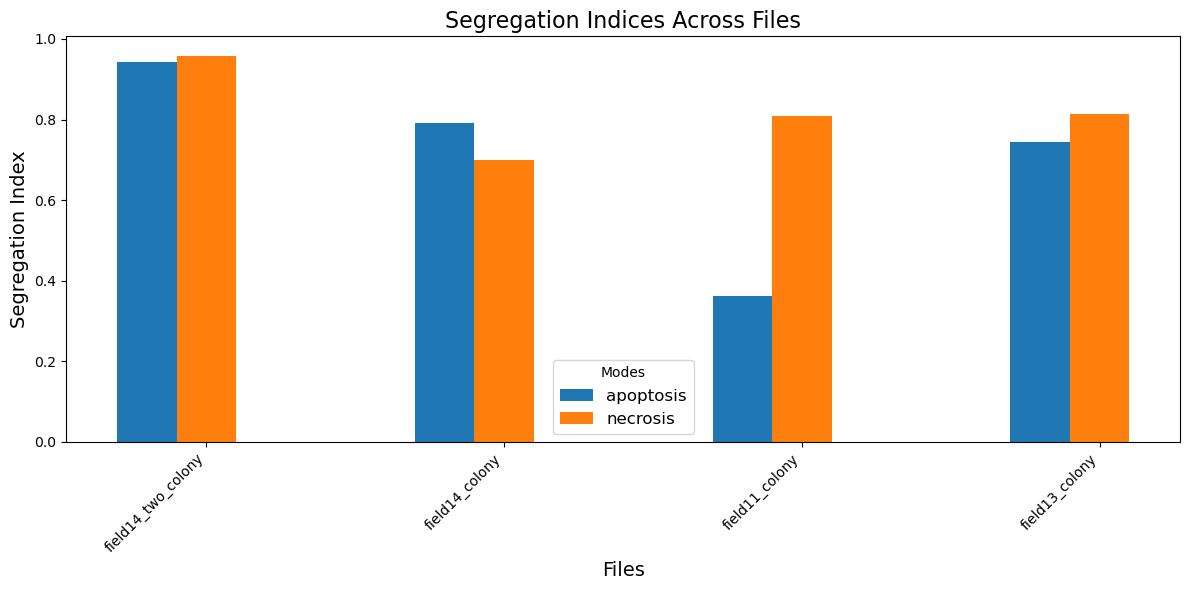

In [18]:
import matplotlib.pyplot as plt

def plot_segregation_indices(res):
    """
    Plots segregation indices for different modes across files.

    Parameters:
    - res: dict, dictionary containing filenames as keys and segregation indices as values
    """
    files = list(res.keys())
    modes = list(res[files[0]].keys())  # Extract modes from the first file
    mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

    x = range(len(files))  # X-axis positions for files
    width = 0.2  # Width of each bar

    plt.figure(figsize=(12, 6))
    for i, mode in enumerate(modes):
        plt.bar([pos + i * width for pos in x], mode_values[mode], width, label=mode)

    plt.xticks([pos + width for pos in x], files, rotation=45, ha='right')
    plt.title("Segregation Indices Across Files", fontsize=16)
    plt.xlabel("Files", fontsize=14)
    plt.ylabel("Segregation Index", fontsize=14)
    plt.legend(title="Modes", fontsize=12)
    plt.tight_layout()
    plt.grid(False)
    plt.show()

# Example usage
plot_segregation_indices(plot_res_dict)

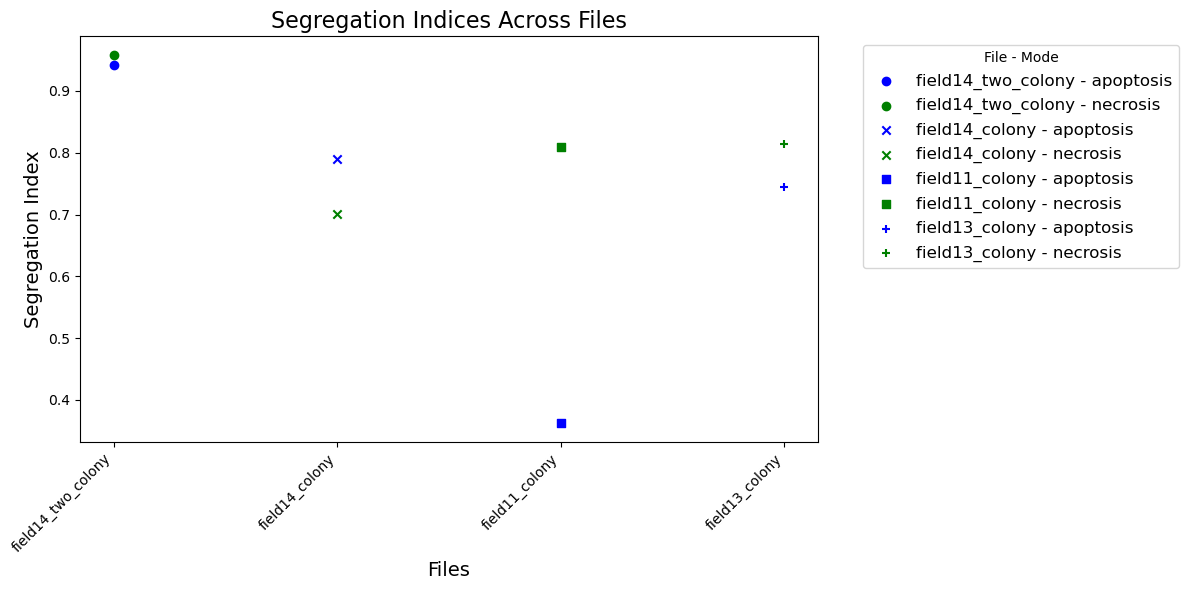

In [19]:
import matplotlib.pyplot as plt

def plot_segregation_indices(res):
    """
    Plots segregation indices for different modes across files using scatter plot.

    Parameters:
    - res: dict, dictionary containing filenames as keys and segregation indices as values
    """
    
    files = list(res.keys())
    modes = list(res[files[0]].keys())  # Extract modes from the first file
    mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

    markers = ['o', 'x', 's', '+', '^', 'v']  # Define markers for files
    colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']  # Define colors for modes
    mode_color_dict = {mode: colors[i % len(colors)] for i, mode in enumerate(modes)}
    file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

    plt.figure(figsize=(12, 6))
    for file_idx, file in enumerate(files):
        for mode in modes:
            plt.scatter(file_idx, res[file][mode], marker=file_marker_dict[file], color=mode_color_dict[mode], label=f"{file} - {mode}")

    plt.xticks(range(len(files)), files, rotation=45, ha='right')
    plt.title("Segregation Indices Across Files", fontsize=16)
    plt.xlabel("Files", fontsize=14)
    plt.ylabel("Segregation Index", fontsize=14)
    plt.legend(title="File - Mode", fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(False)
    plt.show()

# Example usage
plot_segregation_indices(plot_res_dict)

# SPI in mixed colonies

In [20]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/Others/UpdatedMetaData.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
def simple_treatment(name):
    # if "field" in name.lower():
    #     return "FB"
    if "nec" in name.lower():
        return "NecrosisInColonies"
    elif "apop" in name.lower():
        return "ApoptosisInColonies"
    else:
        if "_A" in name:
            return "MixedSubApop"
        elif "_N" in name:
            return "MixedSubNec"
        return "MixedColony"

In [25]:
all_previous_experiments_spi_and_ni_regeneration = calc_all_experiments_SPI_and_NI_for_landscape(list(exp_names),exps_dir_path=exps_dir_name,
                                                                                                 meta_data_full_file_path=meta_data_file_full_path,
                                                                                                 dist_threshold=50,
                                                                                                 filter_neighbors_by_distance = 1,
                                                                                                 filter_neighbors_by_level = 1,)
reformatting_all_previos_experiments_spi_and_ni_regeneration = {"Experiment_name":[],
                                                                "SPI":[],
                                                                "NI":[],
                                                                "Treatment":[],
                                                                "Cell Line + Treatment":[],
                                                                "Cell Line":[],
                                                                "Origin":[],
                                                                "Mode":[],
                                                                "Density":[],}
for key,value in all_previous_experiments_spi_and_ni_regeneration.items():
    if value is None or "--19" in key or "mixed" in simple_treatment(key):
        continue
    origin = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Origin"].values[0]
    mode = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Mode"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Origin"].append(origin)
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Mode"].append(mode)
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Experiment_name"].append(key)
    exp_cell_line= meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"]== key]["Cell Line"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["SPI"].append(value[0])
    reformatting_all_previos_experiments_spi_and_ni_regeneration["NI"].append(value[1])
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line"].append(exp_cell_line)
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line + Treatment"].append(replace_ugly_long_name(key,exp_cell_line))
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Treatment"].append(simple_treatment(key))
    density = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Density(#Cells)"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Density"].append(density)

In [26]:
reformatting_all_previos_experiments_spi_and_ni_regeneration_df = pd.DataFrame(reformatting_all_previos_experiments_spi_and_ni_regeneration)
reformatting_all_previos_experiments_spi_and_ni_regeneration_df
merged_df = reformatting_all_previos_experiments_spi_and_ni_regeneration_df[reformatting_all_previos_experiments_spi_and_ni_regeneration_df["Origin"]!='field3_colony']
merged_df['segregationIndex'] = merged_df.apply(
    lambda row: plot_res_dict.get(row['Origin'], {}).get(row['Mode'].lower(), None),
    axis=1
)

/tmp/ipykernel_3670082/55378466.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['segregationIndex'] = merged_df.apply(


In [27]:
merged_df

,Experiment_name,SPI,NI,Treatment,Cell Line + Treatment,Cell Line,Origin,Mode,Density,segregationIndex
0,field13_crop-001_ROI#1_annotation_apop.csv,0.094462,0.202532,ApoptosisInColonies,MCF10A+field13_crop-001_roi#1_annotation_apop.csv,MCF10A,field13_colony,Apoptosis,237,0.744203
1,field13_crop-001_ROI#1_annotation_nec.csv,0.310123,0.126214,NecrosisInColonies,MCF10A+field13_crop-001_roi#1_annotation_nec.csv,MCF10A,field13_colony,Necrosis,309,0.814844
2,Field14-002_ROI#1_annotation_apop.csv,0.171574,0.186047,ApoptosisInColonies,MCF10A+field14-002_roi#1_annotation_apop.csv,MCF10A,field14_colony,Apoptosis,387,0.790362
3,Field14-002_ROI#1_annotation_nec.csv,0.309192,0.160643,NecrosisInColonies,MCF10A+field14-002_roi#1_annotation_nec.csv,MCF10A,field14_colony,Necrosis,249,0.700311
6,7-20-23_10arednuclei_ROI#10_annotation_apop.csv,-0.499196,0.297872,ApoptosisInColonies,MCF10A+7-20-23_10arednuclei_roi#10_annotation_...,MCF10A,field11_colony,Apoptosis,47,0.362057
7,7-20-23_10arednuclei_ROI#10_annotation_nec.csv,0.372430,0.176056,NecrosisInColonies,MCF10A+7-20-23_10arednuclei_roi#10_annotation_...,MCF10A,field11_colony,Necrosis,142,0.808920
8,7-20-23_10arednuclei_ROI#13_or14_both_colonies...,0.247358,0.145161,ApoptosisInColonies,MCF10A+7-20-23_10arednuclei_roi#13_or14_both_c...,MCF10A,field14_two_colony,Apoptosis,248,0.942593
9,7-20-23_10arednuclei_ROI#13_or14_both_colonies...,0.577353,0.100865,NecrosisInColonies,MCF10A+7-20-23_10arednuclei_roi#13_or14_both_c...,MCF10A,field14_two_colony,Necrosis,348,0.958632


## SPI vs NI

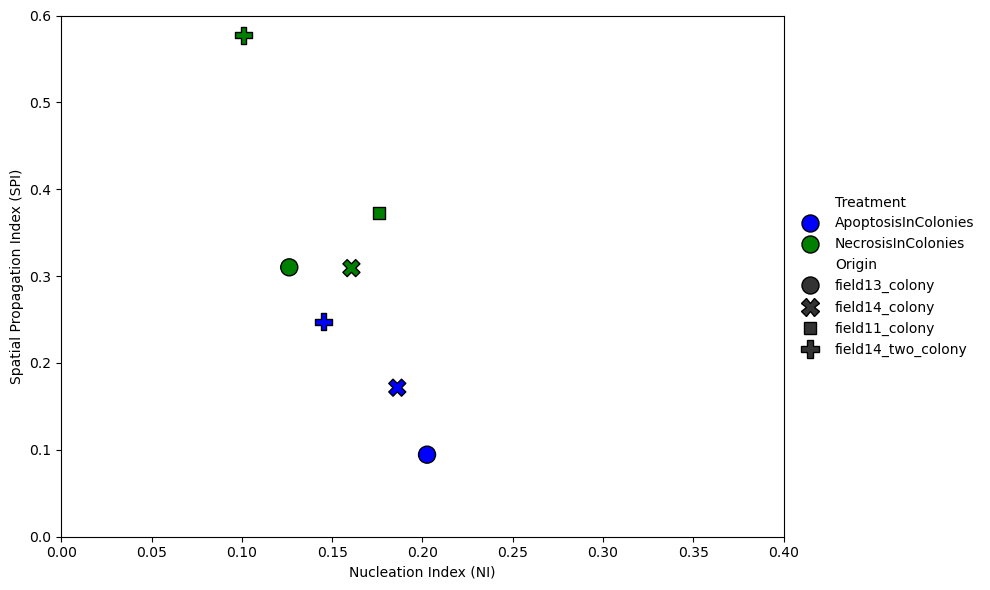

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the custom palette
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}

# Example scatterplot using the custom palette
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=merged_df,  # Replace with your DataFrame
    x="NI",
    y="SPI",
    hue="Treatment",  # Column to map to colors
    style="Origin",   # Column to map to marker styles
    palette=custom_palette,  # Apply the custom palette
    edgecolor="black",
    linewidth=1,
    s=150,
    ax=ax
)

# Customize labels and legend
ax.set_xlabel("Nucleation Index (NI)")
ax.set_ylabel("Spatial Propagation Index (SPI)")
# Place the legend outside the plot box
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
ax.set_xlim(0, 0.4)
ax.set_ylim(0, 0.6)

plt.tight_layout()
plt.show()


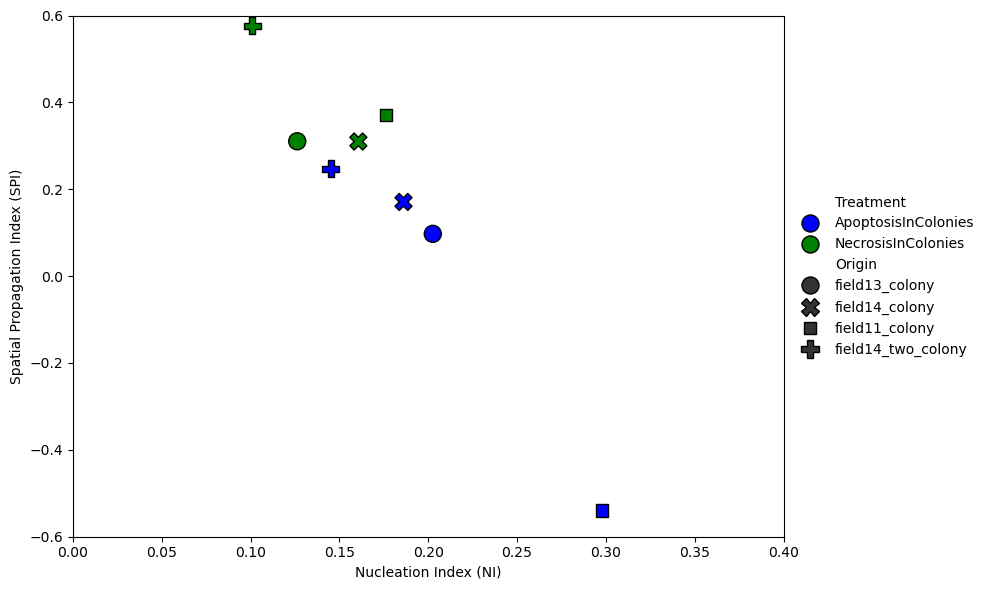

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the custom palette
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}

# Example scatterplot using the custom palette
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=merged_df,  # Replace with your DataFrame
    x="NI",
    y="SPI",
    hue="Treatment",  # Column to map to colors
    style="Origin",   # Column to map to marker styles
    palette=custom_palette,  # Apply the custom palette
    edgecolor="black",
    linewidth=1,
    s=150,
    ax=ax
)

# Customize labels and legend
ax.set_xlabel("Nucleation Index (NI)")
ax.set_ylabel("Spatial Propagation Index (SPI)")
# Place the legend outside the plot box
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
ax.set_xlim(0, 0.4)
ax.set_ylim(-0.6, 0.6)

plt.tight_layout()
plt.show()


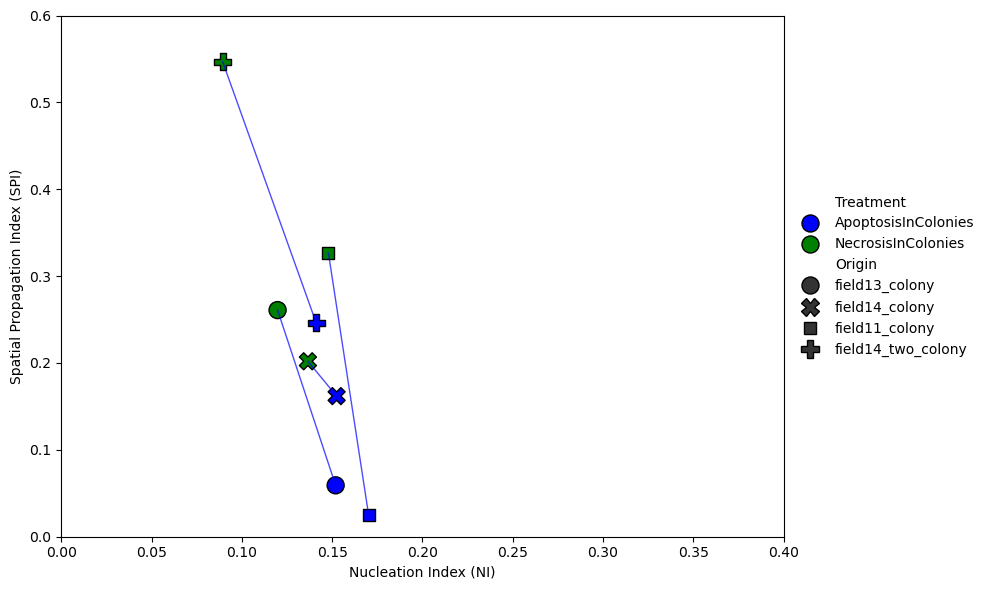

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the custom palette
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}

# Example scatterplot using the custom palette
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=merged_df,
    x="NI",
    y="SPI",
    hue="Treatment",
    style="Origin",
    palette=custom_palette,
    edgecolor="black",
    linewidth=1,
    s=150,
    ax=ax
)

# Add connecting lines between points from the same origin
for origin, group in merged_df.groupby("Origin"):
    ax.plot(group["NI"], group["SPI"], linestyle='-', linewidth=1, alpha=0.7, color = 'b')

# Customize labels and legend
ax.set_xlabel("Nucleation Index (NI)")
ax.set_ylabel("Spatial Propagation Index (SPI)")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
ax.set_xlim(0, 0.4)
ax.set_ylim(0, 0.6)

plt.tight_layout()
plt.show()


## Segregation index

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=merged_df,
    x="Origin",
    y="segregationIndex",
    hue="Treatment",  # Column to map to colors
    style="Origin",   # Column to map to marker styles
    palette=custom_palette,  # Apply the custom palette
    edgecolor="black",
    linewidth=1,
    s=150,
    ax=ax
)

# Customize labels and legend
ax.set_xlabel("Origin")
ax.set_ylabel("Segregation Index")
# Place the legend outside the plot box
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()
